### Análisis de procesos: Planta de tratamiento de aguas residuales urbanas

Analísis de datos de operación de una planta de tratamiento de aguas residuales urbanas a fin de identificar patrones que permitan establecer las condiciones que generan anómalias en la calidad del agua de salida. Los datos provienen de las mediciones diarias de los sensores de la planta  e incluyen el caudal de entrada (Q-E), la concentración parámetros fisicoquímicos del agua (ZN, PH, DBO, DQO, SS, SSV, SED, COND) y datos asociados al rendimiento de las unidades en diferentes etapas del proceso de tratamiento. 

Registros alojados en el repositorio de Machine Learning de la UCI: 
[Water Treatment Plant Dataset – UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/106/water+treatment+plant)

**Diagrama ilustrativo del proceso**:

![Diagrama general del proceso](plantased.png)

#### 1. Exploración preliminar del conjunto de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar
headers = ['Date','Q-E' , 'ZN-E', 'PH-E','DBO-E','DQO-E','SS-E','SSV-E','SED-E','COND-E','PH-P','DBO-P','SS-P','SSV-P','SED-P','COND-P','PH-D','DBO-D',
           'DQO-D','SS-D','SSV-D','SED-D','COND-D','PH-S','DBO-S','DQO-S','SS-S','SSV-S','SED-S','COND-S','RD-DBO-P','RD-SS-P','RD-SED-P','RD-DBO-S',
           'RD-DQO-S','RD-DBO-G','RD-DQO-G','RD-SS-G','RD-SED-G']

df = pd.read_csv('water-treatment.data', names=headers)
df.shape

(527, 39)

In [2]:
df.head(2)

,Date,Q-E,ZN-E,PH-E,DBO-E,DQO-E,SS-E,SSV-E,SED-E,COND-E,...,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-DQO-S,RD-DBO-G,RD-DQO-G,RD-SS-G,RD-SED-G
0,D-1/3/90,44101,1.50,7.8,?,407,166,66.3,4.5,2110,...,2000,?,58.8,95.5,?,70.0,?,79.4,87.3,99.6
1,D-2/3/90,39024,3.00,7.7,?,443,214,69.2,6.5,2660,...,2590,?,60.7,94.8,?,80.8,?,79.5,92.1,100


In [3]:
df.dtypes

Date         object
Q-E          object
ZN-E         object
PH-E        float64
DBO-E        object
DQO-E        object
SS-E         object
SSV-E        object
SED-E        object
COND-E        int64
PH-P        float64
DBO-P        object
SS-P          int64
SSV-P        object
SED-P        object
COND-P        int64
PH-D        float64
DBO-D        object
DQO-D        object
SS-D         object
SSV-D        object
SED-D        object
COND-D        int64
PH-S         object
DBO-S        object
DQO-S        object
SS-S         object
SSV-S        object
SED-S        object
COND-S       object
RD-DBO-P     object
RD-SS-P      object
RD-SED-P     object
RD-DBO-S     object
RD-DQO-S     object
RD-DBO-G     object
RD-DQO-G     object
RD-SS-G      object
RD-SED-G     object
dtype: object

In [4]:
#Valores nulos
df.isnull().any().sum()

np.int64(0)

In [5]:
#Registros marcados con '?'
df.eq('?').sum()

Date         0
Q-E         18
ZN-E         3
PH-E         0
DBO-E       23
DQO-E        6
SS-E         1
SSV-E       11
SED-E       25
COND-E       0
PH-P         0
DBO-P       40
SS-P         0
SSV-P       11
SED-P       24
COND-P       0
PH-D         0
DBO-D       28
DQO-D        9
SS-D         2
SSV-D       13
SED-D       25
COND-D       0
PH-S         1
DBO-S       23
DQO-S       18
SS-S         5
SSV-S       17
SED-S       28
COND-S       1
RD-DBO-P    62
RD-SS-P      4
RD-SED-P    27
RD-DBO-S    40
RD-DQO-S    26
RD-DBO-G    36
RD-DQO-G    25
RD-SS-G      8
RD-SED-G    31
dtype: int64

In [6]:
#Cambio de formato fecha
df['Date'] = (
    df['Date'].astype('str')
        .str.replace('D-', '', regex=False)
        .pipe(pd.to_datetime, format='%d/%m/%y', errors='coerce'))

In [7]:
#Fechas registros
print(df['Date'].min())
print(df['Date'].max())

1990-01-01 00:00:00
1991-10-30 00:00:00


In [8]:
#Cambio a formato numérico
cols = df.columns.difference(['Date'])
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
#Verificación congruencia formato de datos
df.dtypes

Date        datetime64[ns]
Q-E                float64
ZN-E               float64
PH-E               float64
DBO-E              float64
DQO-E              float64
SS-E               float64
SSV-E              float64
SED-E              float64
COND-E               int64
PH-P               float64
DBO-P              float64
SS-P                 int64
SSV-P              float64
SED-P              float64
COND-P               int64
PH-D               float64
DBO-D              float64
DQO-D              float64
SS-D               float64
SSV-D              float64
SED-D              float64
COND-D               int64
PH-S               float64
DBO-S              float64
DQO-S              float64
SS-S               float64
SSV-S              float64
SED-S              float64
COND-S             float64
RD-DBO-P           float64
RD-SS-P            float64
RD-SED-P           float64
RD-DBO-S           float64
RD-DQO-S           float64
RD-DBO-G           float64
RD-DQO-G           float64
R

El conjunto de datos contiene registros de la operación de la planta correspondientes a 527 días, recopilados entre enero de 1990 y octubre de 1991. Durante la inspección de los datos, se identificó la ausencia de información en gran parte de las 38 variables de operación durante el proceso. Asimismo, fue necesario cambiar el tipo de formato de las variables para continuar con el análisis.

### 2. Análisis de datos
El análisis incial se enfocó en la identificación de registros atípicos asociados a la sobrecarga hidráulica y la carga contaminante del afluente, la cual se calculó a partir del caudal y las concentraciones de las variables de operación en cada etapa del proceso.

| Parámetro              | Unidad (concentración / caudal) | Unidad de carga |
|------------------------|----------------------------------|-----------------|
| DBO, DQO               | mg/L O₂                          | kg/d            |
| SS, SSV                | mg/L                             | kg/d            |
| SED                    | mL/L                             | L/d             |
| Caudal                 | m³/d                             | —               |

In [9]:
#Clasificación del tipo de parámetro
param_masa = [
    'DBO-E','DBO-P','DBO-D','DBO-S',
    'DQO-E','DQO-D','DQO-S',
    'SS-E','SS-P','SS-D','SS-S',
    'SSV-E','SSV-P','SSV-D','SSV-S'
]

param_sed = ['SED-E','SED-P', 'SED-D','SED-S']

param_oper = [
    'ZN-E','PH-E','PH-P','PH-D','PH-S',
    'COND-E','COND-P','COND-D','COND-S'
]

In [10]:
#Cálculo de la carga contaminante asociada a parámetros de masa
carga_masa = df[param_masa].multiply(df['Q-E'], axis=0) * 0.001

In [11]:
#Cálculo de la carga contaminante asociada a sedimentos
carga_sed = df[param_sed].multiply(df['Q-E'], axis=0)

In [31]:
#Unificación del conjunto de datos incluyendo redimientos reportados
#cols rdto
cols_rdto = [c for c in df.columns if c.startswith('RD-')]

df_carga = pd.concat(
    [df[['Date','Q-E']],
     carga_masa,
     carga_sed,
     df[param_oper],
    df[cols_rdto]],
    axis=1
)
df_carga.head(2)

,Date,Q-E,DBO-E,DBO-P,DBO-D,DBO-S,DQO-E,DQO-D,DQO-S,SS-E,...,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-DQO-S,RD-DBO-G,RD-DQO-G,RD-SS-G,RD-SED-G
0,1990-03-01,44101.0,NaN,NaN,NaN,NaN,17949.107,12348.280,3704.484,7320.766,...,2000.0,NaN,58.8,95.5,NaN,70.0,NaN,79.4,87.3,99.6
1,1990-03-02,39024.0,NaN,NaN,NaN,NaN,17287.632,18497.376,3551.184,8351.136,...,2590.0,NaN,60.7,94.8,NaN,80.8,NaN,79.5,92.1,100.0


#### 2.1  Tipos de Eventos

Una vez unificado el conjunto de datos con los valores de carga contaminante, se determinó el número de parámetros con valores atípicos por registro. Con base en este conteo, se clasificó el tipo de evento presentado en cada observación según la cantidad de outliers identificados: 
| Tipo de evento | No. de outliers |
|----------------|----------------|
| Puntual        | 1              |
| Operativo      | 2              |
| Severo         | ≥ 3            |


In [13]:
# Parámetros de carga contaminante
cols_carga = param_masa + param_sed

In [14]:
#Determinación de outliers en la carga contaminante
anom_cols = []

for col in cols_carga:
    x = df_carga[col]
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    new_col = f'anom_{col}'
    df_carga[new_col] = (x < li) | (x > ls)
    anom_cols.append(new_col)
# como se suman columnas anomalas con al menos un valor anom?

In [15]:
#Cálculo del número parámetros con valores atípicos
df_carga['n_param_anom'] = df_carga[anom_cols].sum(axis=1)

#Clasificación de eventos
df_carga['tipo_evento'] = 'normal'
df_carga.loc[df_carga['n_param_anom'] == 1, 'tipo_evento'] = 'puntual'
df_carga.loc[df_carga['n_param_anom'] == 2, 'tipo_evento'] = 'operativo'
df_carga.loc[df_carga['n_param_anom'] >= 3, 'tipo_evento'] = 'severo'

In [16]:
#Conjunto de datos de operación solo valores atípicos
mask_outlier = df_carga[anom_cols].any(axis=1)
df_outliers = df_carga.loc[mask_outlier, ['Date', 'Q-E', *cols_carga,'tipo_evento']]

In [17]:
# Registros atípicos
total_outliers = len(df_outliers)
print(f"Total de registros atípicos: {total_outliers}\n")

#Frecuencia por tipo de evento
print(f"Número de eventos por tipo: \n {df_carga['tipo_evento'].value_counts()}")

Total de registros atípicos: 173

Número de eventos por tipo: 
 tipo_evento
normal       354
puntual       94
severo        51
operativo     28
Name: count, dtype: int64


De acuerdo con la clasificación establecida, la planta operó en condiciones normales durante 354 días. Se identificaron 94 eventos puntuales, los cuales pueden atribuirse a fallas aisladas en los sensores o a descargas no recurrentes que generaron cambios temporales en la composición del agua. Asimismo, se registraron 28 eventos operativos, posiblemente asociados a fallas en las unidades de proceso, derivadas de deficiencias en el control operativo o de la acumulación de sólidos. Finalmente, se identificaron 51 eventos catalogados como severos, en los que se presentaron anomalías en tres o más parámetros del análisis fisicoquímico del agua en diferentes etapas del proceso, atribuibles a eventos hidrológicos intensos que podrían haber sobrecargado las unidades de operación y provocado arrastre de sólidos o sobrevertimientos en la planta.

#### 2.2 Anomalías asociadas a la carga de contaminante
El grado de afectación al proceso de tratamiento durante días atípicos asociado a la carga contaminante, se evaluó de acuerdo al número de anomalias presentadas por parámetro :

In [18]:
#Frecuencia de parámetros anómalos
df_carga[anom_cols].sum().sort_values(ascending=False)

anom_SED-S    40
anom_SED-D    37
anom_SS-E     34
anom_SS-S     32
anom_SS-P     28
anom_DQO-S    24
anom_SS-D     21
anom_SSV-E    18
anom_DBO-S    17
anom_DBO-E    15
anom_SED-P    15
anom_SSV-D    13
anom_DQO-E    13
anom_SED-E    12
anom_SSV-S    10
anom_SSV-P    10
anom_DBO-P     8
anom_DQO-D     7
anom_DBO-D     4
dtype: int64

Al analizar el número de valores atípicos por parámetro, se evidenció que, durante los días atípicos, las anomalías se presentaron a lo largo de todo el proceso de tratamiento. Estas se concentraron principalmente en variables asociadas a los sólidos suspendidos (SS) y sedimentables (SED), lo que indica un predominio de procesos de arrastre de sólidos. Asimismo, se registraron anomalías desde la entrada a la planta, lo que sugiere una alteración en las condiciones del afluente que ingresó al sistema de tratamiento y se propagó aguas abajo. En este contexto, es razonable considerar la existencia de ingresos adicionales de caudal no medido en E, asociado posiblemente a recirculaciones internas, infiltraciones o by-pass hidráulicos en diferentes puntos del tren de sedimentadores.

Con el fin de caracterizar los patrones de recurrencia de las anomalías, se estimó la frecuencia relativa con la que cada parámetro presentó cCondiciones anómalas según el tipo de evento:

In [19]:
#Frecuencia relativa de parámetros en condición anómala por tipo de evento
anom_only = [c for c in anom_cols]
df_carga.groupby('tipo_evento')[anom_only].mean().sort_index().style.background_gradient(cmap='Reds',axis=1)

,anom_DBO-E,anom_DBO-P,anom_DBO-D,anom_DBO-S,anom_DQO-E,anom_DQO-D,anom_DQO-S,anom_SS-E,anom_SS-P,anom_SS-D,anom_SS-S,anom_SSV-E,anom_SSV-P,anom_SSV-D,anom_SSV-S,anom_SED-E,anom_SED-P,anom_SED-D,anom_SED-S
tipo_evento,,,,,,,,,,,,,,,,,,,
normal,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
operativo,0.000000,0.071429,0.000000,0.035714,0.035714,0.035714,0.107143,0.214286,0.214286,0.142857,0.250000,0.071429,0.035714,0.107143,0.000000,0.071429,0.035714,0.321429,0.250000
puntual,0.074468,0.031915,0.010638,0.042553,0.031915,0.021277,0.053191,0.063830,0.021277,0.042553,0.085106,0.010638,0.010638,0.021277,0.053191,0.010638,0.031915,0.202128,0.180851
severo,0.156863,0.058824,0.058824,0.235294,0.176471,0.078431,0.313725,0.431373,0.392157,0.254902,0.333333,0.294118,0.156863,0.156863,0.098039,0.176471,0.215686,0.176471,0.313725


Como se puede apreciar en la gráfica, se presentó un incremento progresivo en la frecuencia relativa de anomalías desde los eventos normales hasta los eventos severos, con una mayor recurrencia concentrada en parámetros asociados a SS y SED. En los eventos operativos y puntuales, la perturbación en los sólidos sedimentables se manifiestó de forma localizada en la entrada del sedimentador secundario, donde alcanzó su máxima intensidad. En contraste, los eventos severos se caracterizaron por una perturbación más distribuida a lo largo del proceso, que no se concentró en un único punto, sino que se propagó y se intensificó aguas abajo.

En cuanto a los SS, las perturbaciones se presentaron en todos los tipos de evento desde el ingreso a la planta, propagándose posteriormente a lo largo del tren de tratamiento. En los eventos operativos y severos, se evidencia una atenuación parcial de la perturbación a la salida del sedimentador primario; sin embargo, esta se intensificó nuevamente a la salida del sistema, comportamiento similar al observado para los sólidos sedimentables durante eventos severos.

In [32]:
#diferencias en la carga de SED y SS durante diás normales y días con valores atípicos a la salida del sistema
mask_normal = ~mask_outlier

sed_normal = df_carga.loc[mask_normal, 'SED-S']
sed_outlier    = df_carga.loc[mask_outlier, 'SED-S']
sed_normal, sed_outlier = sed_normal.dropna(), sed_outlier.dropna()

ss_normal  = df_carga.loc[mask_normal, 'SS-S']
ss_outlier     = df_carga.loc[mask_outlier, 'SS-S']
ss_normal,  ss_outlier  = ss_normal.dropna(),  ss_outlier.dropna()

sed_diff_pct = (sed_outlier.median() - sed_normal.median()) / sed_normal.median() * 100
ss_diff_pct  = (ss_outlier.median()  - ss_normal.median())  / ss_normal.median()  * 100

print("Comparación de SED y SS entre días normales y días con outliers\n")

print(f"SED mediana (días normales): {sed_normal.median():.2f} L/d")
print(f"SED mediana (días con outliers): {sed_outlier.median():.2f} L/d\n")

print(f"SS mediana (días normales): {ss_normal.median():.2f} kg/d")
print(f"SS mediana (días con outliers): {ss_outlier.median():.2f} kg/d\n")

print("Diferencia porcentual entre la concentración de sólidos en días normales y días con outliers\n")
print(f"[SED]: {sed_diff_pct:.1f}%")
print(f"[SS]: {ss_diff_pct:.1f}%")

Comparación de SED y SS entre días normales y días con outliers

SED mediana (días normales): 345.13 L/d
SED mediana (días con outliers): 761.10 L/d

SS mediana (días normales): 634.99 kg/d
SS mediana (días con outliers): 786.26 kg/d

Diferencia porcentual entre la concentración de sólidos en días normales y días con outliers

[SED]: 120.5%
[SS]: 23.8%


Adicionalmente, al comparar las cargas de SED y SS a la salida del sistema de tratamiento durante días normales y con valores atípicos, se evidenciaron incrementos marcados en las concentraciones de sólidos a la salida del sistema. En particular, la mediana de SED aumentó en aproximadamente un 120%, mientras que la mediana de SS presentó un incremento cercano al 24% durante los eventos anómalos.  

El patrón de arrastre de sólidos observado entre eventos puntuales y operativos, en comparación con los eventos severos, es compatible con posibles cambios en el régimen hidráulico de la planta bajo condiciones de sobrecarga, como se discutió previamente. En escenarios de mayor severidad, el incremento del caudal podría favorecer la creación de rutas hidráulicas preferenciales y una redistribución de los flujos, alterando el comportamiento secuencial del sistema de sedimentación y limitando la capacidad de las unidades intermedias para retener y amortiguar la carga sólida. En eventos puntuales, en cambio, el sistema operaría más cercano a su régimen de diseño, permitiendo que los sólidos movilizados sean transportados y cuantificados de forma más consistente a lo largo del proceso.

#### 2.3 Anomalías asociadas al caudal
Dado que incrementos significativos en el caudal de ingreso, pueden reducir el tiempo de retención hidráulica y, en consecuencia, afectar la eficiencia de remoción en las distintas unidades en el proceso de tratamiento, se evaluó si las anomalías observadas en la carga contaminante a la salida del sistema se encuentran asociadas a eventos de caudal elevado o a cambios en el régimen hidráulico de la planta.

In [21]:
#Comparación entre valores de caudal en días con registros atípicos y de operación normal
mean_normal = df_carga.loc[~mask_outlier, 'Q-E'].mean()
mean_outlier = df_carga.loc[mask_outlier, 'Q-E'].mean()

median_normal = df_carga.loc[~mask_outlier, 'Q-E'].median()
median_outlier = df_carga.loc[mask_outlier, 'Q-E'].median()

pct_diff_mean = ((mean_outlier - mean_normal) / mean_normal) * 100
pct_diff_median = ((median_outlier - median_normal) / median_normal) * 100

print("Comparación de caudal entre días normales y días con outliers\n")
print(f"Caudal promedio (días normales): {mean_normal:.2f} m³/d")
print(f"Caudal promedio (días con outliers): {mean_outlier:.2f} m³/d\n")

print(f"Caudal mediano (días normales): {median_normal:.2f} m³/d")
print(f"Caudal mediano (días con outliers): {median_outlier:.2f} m³/d\n")

print("Diferencia porcentual entre el caudal en días normales y días con outliers\n")
print(f"Caudal (media): {pct_diff_mean:.1f}%")
print(f"Caudal (mediana): {pct_diff_median:.1f}%")

Comparación de caudal entre días normales y días con outliers

Caudal promedio (días normales): 36055.95 m³/d
Caudal promedio (días con outliers): 39500.13 m³/d

Caudal mediano (días normales): 34886.00 m³/d
Caudal mediano (días con outliers): 38620.00 m³/d

Diferencia porcentual entre el caudal en días normales y días con outliers

Caudal (media): 9.6%
Caudal (mediana): 10.7%


Al comparar la magnitud del caudal en días de operación normal y días con registros atípicos, se evidenció un incremento consistente del caudal del orden del 10% durante los eventos anómalos, tanto en términos de media como de mediana. Es decir, que este comportamiento no es solo atribuible a valores atípicos que puedan distorcionar el comportamiento de la planta sino que muestra un cambio sistemático en su régimen hidráulico.  

In [22]:
#Análisis del número de registros atípicos durante eventos de caudal extremo

#percentices de caudal 75,90,95
q75 = df_carga['Q-E'].quantile(0.75)
q90 = df_carga['Q-E'].quantile(0.90)
q95 = df_carga['Q-E'].quantile(0.95)

# % outliers
pct_out_q75 = (df_outliers['Q-E'] > q75).mean() * 100
pct_out_q90 = (df_outliers['Q-E'] > q90).mean() * 100
pct_out_q95 = (df_outliers['Q-E'] > q95).mean() * 100

# % total registros
pct_all_q75 = (df_carga['Q-E'] > q75).mean() * 100
pct_all_q90 = (df_carga['Q-E'] > q90).mean() * 100
pct_all_q95 = (df_carga['Q-E'] > q95).mean() * 100

print("Porcentaje de outliers bajo condiciones de caudal elevado:")
print(f"- Caudal > P75 : {pct_out_q75:.1f}%")
print(f"- Caudal > P90 : {pct_out_q90:.1f}%")
print(f"- Caudal > P95 : {pct_out_q95:.1f}%\n")

print("Porcentaje de días con caudal elevado en el dataset completo:")
print(f"- Caudal > P75 : {pct_all_q75:.1f}%")
print(f"- Caudal > P90 : {pct_all_q90:.1f}%")
print(f"- Caudal > P95 : {pct_all_q95:.1f}%")

Porcentaje de outliers bajo condiciones de caudal elevado:
- Caudal > P75 : 39.3%
- Caudal > P90 : 17.3%
- Caudal > P95 : 8.7%

Porcentaje de días con caudal elevado en el dataset completo:
- Caudal > P75 : 24.1%
- Caudal > P90 : 9.7%
- Caudal > P95 : 4.9%


Asimismo, al analizar la distribución de los registros atípicos en función de distintos percentiles del caudal de entrada, comparando su frecuencia relativa con el comportamiento global del sistema, se determinó que, de acuerdo a los resultados obtenidos, el 24.1% del total de registros presentó caudales elevados, definidos como valores superiores al percentil 75, de estos, el 39.3% correspondió a eventos atípicos. En el caso de eventos hidrológicos más intensos, asociados a caudales superiores al percentil 90, si bien su ocurrencia es menos frecuente, presentan una probabilidad significativa de generar fallas operativas (Caudal > P90 : 17.3%; Caudal > P95 : 8.7%). 

Estos resultados reflejan una relación clara entre el incremento del caudal y la aparición de anomalías operativas, indicando que, a medida que el régimen hidráulico se vuelve más extremo y se produce una sobrecarga hidráulica del sistema, aumenta la probabilidad de que se generen procesos de arrastre o resuspención de sólidos y, en consecuencia, de una disminución en la eficiencia del proceso de tratamiento. Si bien, los resultados obtenidos indican que solo una fracción de las anomalías en la carga de salida se presenta durante eventos de caudal elevado. La presencia de registros atípicos bajo regímenes hidráulicos normales evidencia que el caudal no es el único factor determinante, y que otros aspectos o procesos pueden contribuir a la variabilidad observada.

#### 2.4 Variación en la concentración de SS y SED
Al analizar la variación en la concentración de SS y SED, se estableció que la concentración del afluente que ingresó al tren de sedimentadores presentó incrementos en gran parte de los registros respecto de la concentración medida en E al ingreso a la planta.  Estas variaciones se presentaron para todos los tipos de eventos según la clasificación propuesta, considerando incluso el caudal mínimo registrado. 

In [23]:
#filtro df con variables de interés
df_carga_filt = df_carga.loc[df_carga['Q-E'] >= median_normal, ['SS-E','SS-P','SS-D','SS-S','SED-E','SED-P','SED-D','SED-S','tipo_evento']]

#Variaciones en la concentración de SS durante eventos con caudal mayor o igual a la mediana del caudal en días átipicos - Incrementos por etapas
pct_etapas =  df_carga_filt[['SS-E','SS-P','SS-D','SS-S']].diff(axis=1)
pct_etapas.columns = ['Δ% EP', 'Δ% E→P', 'Δ% P→D', 'Δ% D→S']
pct_etapas = pct_etapas.iloc[:,1:]
(pct_etapas > 0).sum()

Δ% E→P    210
Δ% P→D      0
Δ% D→S      4
dtype: int64

In [24]:
#Variaciones en la concentración de SED durante eventos con caudal mayor o igual a la mediana del caudal en días átipicos - Incrementos por etapas
pct_etapas_sed =  df_carga_filt[['SED-E','SED-P','SED-D','SED-S']].diff(axis=1)
pct_etapas_sed.columns = ['Δ% EP', 'Δ% E→P', 'Δ% P→D','Δ% D→S']
pct_etapas_sed = pct_etapas_sed.iloc[:,1:]
display(pct_etapas_sed.shape)
#aumento en la cancentración respecto de la etapa anterior
(pct_etapas_sed > 0).sum()

(294, 3)

Δ% E→P    143
Δ% P→D      0
Δ% D→S      3
dtype: int64

El aporte de carga contaminante adicional en P fue amortiguado por el sedimentador primario, sin embargo, en el sedimentador secundario, se registraron, aunque en menor medida, concentraciones de sólidos a la salida superiores a las registradas a la entrada. Este comportamiento podría ser atribuible con un ingreso de caudal adicional a la unidad como consecuencia de la creación de rutas hidráulicas alternas a las de diseño o a fallas en el mantenimiento operativo del tren de tratamiento, lo que habría generado el arrastre o resuspención de sólidos.

### 2.5 Estacionalidad

Para identificar si hay factores de estacionalidad asociados a las variaciones del régimen hidráulico o la ocurrencia de cargas atípicas en el efluente de la planta de tratamiento, se analizó la distribución temporal de los datos de operación.

In [25]:
df_carga['year'] = df_carga['Date'].dt.year
df_carga['month'] = df_carga['Date'].dt.month

#Número de registros por año
year_even = df_carga['year'].value_counts().sort_index()
print("Número de eventos por año:")
for year, n in year_even.items():
    print(f"  • {year}: {n}")

Número de eventos por año:
  • 1990: 300
  • 1991: 227


In [26]:
#Número de registros atípicos por mes y año
month_even = (df_carga.groupby(['year','month']).size().unstack(fill_value=0))
print("Número de eventos por mes y año:")
display(month_even)

Número de eventos por mes y año:


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1990,26,23,26,23,26,25,27,26,24,25,26,23
1991,27,23,25,25,27,23,27,25,0,25,0,0


In [27]:
#Número de registros totales y atípicos por día
day_even = df_carga['Date'].dt.day_name().value_counts()
print("Número de registros por día de la semana: \n")
print(day_even)

Número de registros por día de la semana: 

Date
Friday       90
Wednesday    89
Sunday       87
Tuesday      87
Thursday     85
Monday       84
Saturday      5
Name: count, dtype: int64


Los registros corresponden a enero - diciembre de 1990 y enero - octubre 1991. No se cuenta con registros de septiembre de 1991.
El número de registros por día de la semana se encuentra desbalanceado. La cantidad de datos disponibles, particularmente para el día sabado, es reducida. Esta falta de información limita la precisión del análisis estacional.

In [28]:
eventos_tipo = (df_carga.groupby(['year', 'tipo_evento']).size().unstack(fill_value=0).sort_index())
print("Número de eventos por año y tipo:")
display(eventos_tipo)

Número de eventos por año y tipo:


tipo_evento,normal,operativo,puntual,severo
year,,,,
1990,179,22,61,38
1991,175,6,33,13


In [29]:
tabla = df_carga.query("tipo_evento != 'normal'") \
                .groupby(['month','year','tipo_evento']) \
                .size() \
                .unstack(['year','tipo_evento'], fill_value=0)
print("Número de eventos por mes y tipo: \n")
tabla.style.background_gradient(cmap='Reds',axis=0)

Número de eventos por mes y tipo: 



En general, el primer sementre del año concentró la mayor parte de eventos atípicos, salvo por los eventos puntutales que se concentran en su mayoría, al inicio (enero), mediados ( marzo- mayo) y finales ( octubre) del año. La mayor cantidad de eventos operativos se presentó durante el mes de mayo de 1990 y los eventos severos durante el primer semestre del año con mayor magnitud en los meses de mayo y junio.  Los meses de mayo y octubre destacan como periodos críticos, concentrando 18 y 11 eventos atípicos en mayo, y 14 y 8 eventos atípicos en octubre durante 1990 y 1991, respectivamente. Esta recurrencia podría estar asociada a periodos de mayor variabilidad hidrológica, donde el incremento en el caudal de entrada puede generar condiciones de sobrecarga hidráulica. 

Al comparar los datos, se observa una disminución en la frecuencia de registros con eventos atípicos durante el segundo año de operación, lo que sugiere una mayor estabilidad operativa del sistema o condiciones hidráulicas menos exigentes durante ese periodo.

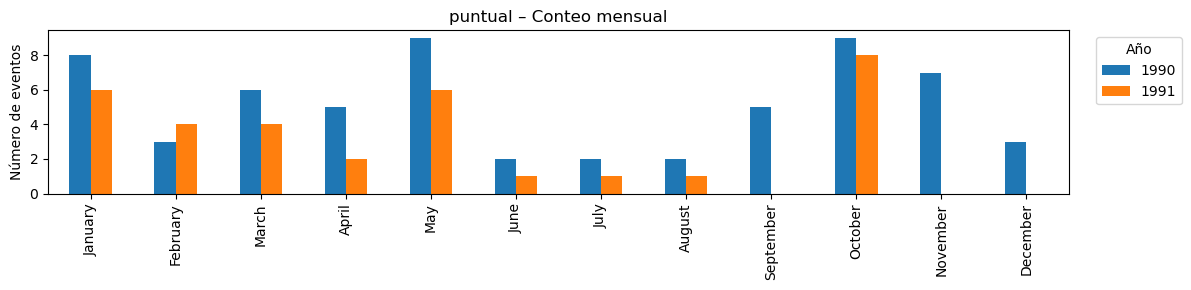

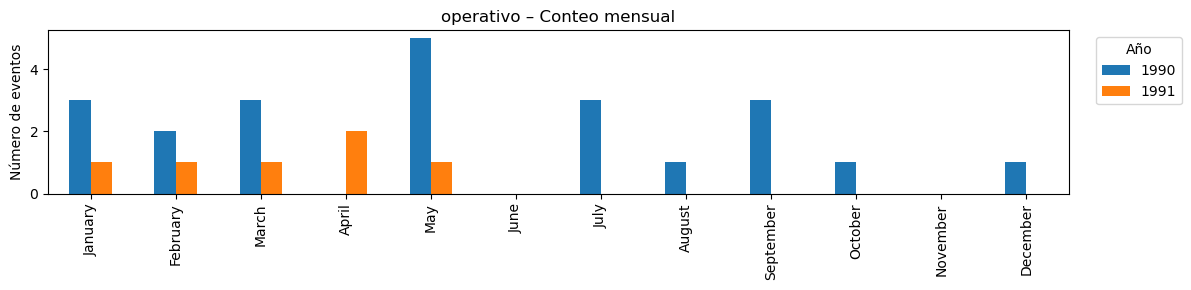

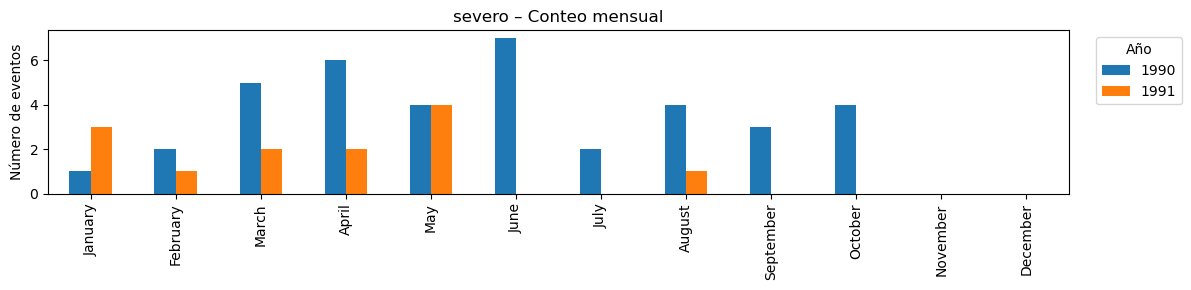

In [30]:
eventos = (df_carga.loc[df_carga['tipo_evento'] != 'normal', 'tipo_evento'].unique())

for evento in eventos:
    out = (df_carga.query("tipo_evento == @evento").groupby(['year', 'month']).size().unstack(fill_value=0).reindex(columns=range(1, 13), fill_value=0))
    out.columns = [calendar.month_name[m] for m in out.columns]

    ax = out.T.plot(kind='bar', figsize=(12, 3), ylabel='Número de eventos', title=f'{evento} – Conteo mensual')
    ax.legend(title='Año', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Conclusiones y recomendaciones

Los resultados hacen evidente una falla en la operación de la planta antes del ingreso del afluente al sedimentador primario. Los incrementos en la concentración de sólidos, atribuibles a la ocurrencia de caudales elevados o ingresos adicionales durante días atípicos, reflejan deficiencias en el monitoreo y en la capacitación de personal encargado de la medición de los parámetros fisicoquímicos. Esta situación afectó la trazabilidad del proceso de tratamiento. 

Asimismo, estos incrementos evidencian el impacto de la sobrecarga hidráulica, la cual reduce la eficiencia del proceso de tratamiento. No obstante, la variabilidad en el caudal de operación solo explica parcilamente las anomalías observadas, por lo que también deben considerarse factores operativos y de monitoreo. 

Con la estabilización de la operación de planta, se alcanzó una reducción significativa en el número de eventos atípicos. Sin embargo, no se realizó monitoreo de la operación durante los días sábado y no se dispone con información de la operación de los meses de septiembre, noviembre y diciembre de 1991, lo que limita el análisis.

Gran parte de los eventos atípicos se presentaron durante el primer semestre del año, con algunos adicionales durante los meses de octubre y noviembre, posiblemente asociados a condiciones climatológicas estacionales. Se identificaron mayo y octubre como meses críticos, en los que se recomienda implementar medidas especiales para mitigar la variabilidad del caudal durante eventos hidrológicos intensos.

#### Recomendaciones

* Evaluar el estado estructural de las unidades de tratamiento para identificar posibles fallas o averías.
* Identificar y monitorear rutas hidráulicas alternas que se generen durante eventos de alta precipitación, con el fin de evaluar su impacto en la distribución del flujo y en la eficiencia del tratamiento.
* Diseñar e implementar un plan de acción para mitigar la variabilidad del caudal durante temporadas de alta precipitación.
* Estandarizar la frecuencia y los protocolos de monitoreo de las condiciones operativas de la planta.
* Establecer un cronograma de mantenimiento preventivo que incluya la remoción periódica de lodos acumulados y la eliminación de zonas muertas que favorezcan el arrastre de sólidos.